# Sneha Singh
## DATA 266 — Homework 6
Self-supervised and contrastive representation learning on STL-10

Same backbone for every part: ResNet-18, no pretrained weights.


In [3]:
# libraries for this homework
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from torchvision.datasets import STL10

# last 4 of my SJSUid - 0670
SID4 = 670
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

ROOT = Path("data")
CKPT = Path("checkpoints")
FIG = Path("figures")
ROOT.mkdir(exist_ok=True)
CKPT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)
print("device:", DEVICE)
print("HP_ID is reported only. no extra HP model this hw")
print("three models = supervised, rotation SSL, SimCLR")


SID4: 670
SEED: 670
SLICE: 670
HP_ID: 4
CLS_A: 0
CLS_B: 5
device: cuda
HP_ID is reported only. no extra HP model this hw
three models = supervised, rotation SSL, SimCLR


This assignment said follow the same step 0 as assignment 1. I did not copy the HW1 diabetes notebook. I only reused the standing parameters: SID4=670, SEED=670, SLICE=670, HP_ID=4, CLS_A=0, CLS_B=5, and I seeded python / numpy / torch with 670.

HW1 used HP_ID for a second network (15 vs 30 epochs). This assignment said skip that, because the three models are already the supervised net, the rotation encoder, and SimCLR.

Run this on a Colab GPU. Part A is only 500 images. Part B is all 100,000 unlabeled images for 15 epochs. Part C is 20,000 unlabeled images, two views, for 15 epochs. That is too long for my Mac.


## 0. Data

STL-10. Train split is 5,000 labeled images. I take 10% of that, so 500 images, and I reuse that same index list in Parts A, B, and C. Test split is 8,000 images. Unlabeled split is 100,000 images. Part C uses the first 20,000 of a seed-670 shuffle of the unlabeled split.


In [5]:
STL_MEAN = (0.4467, 0.4398, 0.4066)
STL_STD = (0.2603, 0.2566, 0.2713)

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL_MEAN, STL_STD),
])

train_labeled = STL10(ROOT, split="train", download=True, transform=eval_tf)
test_set = STL10(ROOT, split="test", download=True, transform=eval_tf)
unlabeled_raw = STL10(ROOT, split="unlabeled", download=True)

g = torch.Generator().manual_seed(SEED)
labeled_idx = torch.randperm(len(train_labeled), generator=g)[:500].tolist()
unlab_perm = torch.randperm(len(unlabeled_raw), generator=g)[:20000].tolist()

torch.save(labeled_idx, CKPT / "labeled_10pct_idx.pt")
torch.save(unlab_perm, CKPT / "simclr_20k_idx.pt")

print("labeled train:", len(train_labeled))
print("10% subset:", len(labeled_idx))
print("test:", len(test_set))
print("unlabeled:", len(unlabeled_raw))
print("simclr subset:", len(unlab_perm))
print("classes:", train_labeled.classes)


100%|██████████| 2.64G/2.64G [04:49<00:00, 9.13MB/s]


labeled train: 5000
10% subset: 500
test: 8000
unlabeled: 100000
simclr subset: 20000
classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [6]:
def make_encoder():
    net = models.resnet18(weights=None)
    net.fc = nn.Identity()
    return net

def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

def run_epochs(model, loader, opt, epochs, eval_loader=None, name="", contrastive=False):
    rows = []
    for epoch in range(1, epochs + 1):
        model.train()
        if contrastive and hasattr(model, "encoder"):
            # BN stats stay fixed only during the linear probe, not here
            pass
        total = 0.0
        n = 0
        for batch in loader:
            if contrastive:
                v1, v2 = batch
                v1 = v1.to(DEVICE)
                v2 = v2.to(DEVICE)
                loss = model(v1, v2)
                bs = v1.size(0)
            else:
                x, y = batch
                x = x.to(DEVICE)
                y = y.to(DEVICE)
                loss = F.cross_entropy(model(x), y)
                bs = y.size(0)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * bs
            n += bs
        acc = accuracy(model, eval_loader) if eval_loader is not None else None
        row = {"epoch": epoch, "loss": total / n, "acc": acc}
        rows.append(row)
        if acc is None:
            print(f"{name} epoch {epoch:02d}  loss {row['loss']:.4f}")
        else:
            print(f"{name} epoch {epoch:02d}  loss {row['loss']:.4f}  acc {acc:.4f}")
    return rows


## Part A — Supervised, 10% labels

I train ResNet-18 end to end on the 500-image subset for 12 epochs. The last layer is a linear classifier with 10 classes. Test accuracy is on the full 8,000-image test split.


In [7]:
class SupervisedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = make_encoder()
        self.head = nn.Linear(512, 10)

    def forward(self, x):
        return self.head(self.encoder(x))

    def embed(self, x):
        return self.encoder(x)

labeled_subset = Subset(train_labeled, labeled_idx)
train_loader_a = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

torch.manual_seed(SEED)
model_a = SupervisedNet().to(DEVICE)
opt_a = torch.optim.Adam(model_a.parameters(), lr=1e-3)
print("Part A trainable params:", count_params(model_a))
rows_a = run_epochs(model_a, train_loader_a, opt_a, 12, test_loader, "A")
acc_a = accuracy(model_a, test_loader)
print("Part A test accuracy:", round(acc_a, 4))
torch.save(model_a.state_dict(), CKPT / "part_a.pt")


Part A trainable params: 11181642
A epoch 01  loss 2.1182  acc 0.1477
A epoch 02  loss 1.3963  acc 0.3006
A epoch 03  loss 0.7879  acc 0.3049
A epoch 04  loss 0.3193  acc 0.2749
A epoch 05  loss 0.1734  acc 0.3241
A epoch 06  loss 0.1310  acc 0.3065
A epoch 07  loss 0.1663  acc 0.3074
A epoch 08  loss 0.1539  acc 0.2727
A epoch 09  loss 0.1343  acc 0.3129
A epoch 10  loss 0.1116  acc 0.3284
A epoch 11  loss 0.1223  acc 0.3152
A epoch 12  loss 0.1047  acc 0.3426
Part A test accuracy: 0.3426


## Part B — Rotation self-supervised learning

I use every unlabeled image. Each image is rotated by 0, 90, 180, or 270 degrees, and the network has to predict which one. I train that for 15 epochs.

Then I drop the 4-way rotation head, freeze the encoder, and train only a new linear layer on the same 500 labeled images for 15 epochs.


In [8]:
class RotationSet(Dataset):
    def __init__(self, base):
        self.base = base
        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(STL_MEAN, STL_STD),
        ])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        img, _ = self.base[i]
        k = random.randint(0, 3)
        img = img.rotate(k * 90)
        x = self.tf(img)
        return x, k

class RotationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = make_encoder()
        self.head = nn.Linear(512, 4)

    def forward(self, x):
        return self.head(self.encoder(x))

rot_loader = DataLoader(RotationSet(unlabeled_raw), batch_size=128, shuffle=True, num_workers=2)
torch.manual_seed(SEED)
model_b_pre = RotationNet().to(DEVICE)
opt_b = torch.optim.Adam(model_b_pre.parameters(), lr=1e-3)
print("Part B pretrain params:", count_params(model_b_pre))
rows_b_pre = run_epochs(model_b_pre, rot_loader, opt_b, 15, name="B-rot")
torch.save(model_b_pre.state_dict(), CKPT / "part_b_rotation.pt")

class LinearProbe(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(512, 10)
        for p in self.encoder.parameters():
            p.requires_grad = False

    def train(self, mode=True):
        super().train(mode)
        self.encoder.eval()
        return self

    def forward(self, x):
        with torch.no_grad():
            z = self.encoder(x)
        return self.head(z)

    def embed(self, x):
        self.encoder.eval()
        with torch.no_grad():
            return self.encoder(x)

model_b = LinearProbe(model_b_pre.encoder).to(DEVICE)
opt_b_lin = torch.optim.Adam(model_b.head.parameters(), lr=1e-3)
print("Part B linear params (encoder frozen):", count_params(model_b))
rows_b = run_epochs(model_b, train_loader_a, opt_b_lin, 15, test_loader, "B-lin")
acc_b = accuracy(model_b, test_loader)
print("Part B test accuracy:", round(acc_b, 4))
torch.save({"encoder": model_b_pre.encoder.state_dict(), "head": model_b.head.state_dict()}, CKPT / "part_b_linear.pt")


Part B pretrain params: 11178564
B-rot epoch 01  loss 0.9340
B-rot epoch 02  loss 0.7351
B-rot epoch 03  loss 0.6414
B-rot epoch 04  loss 0.5728
B-rot epoch 05  loss 0.5256
B-rot epoch 06  loss 0.4877
B-rot epoch 07  loss 0.4576
B-rot epoch 08  loss 0.4265
B-rot epoch 09  loss 0.4051
B-rot epoch 10  loss 0.3799
B-rot epoch 11  loss 0.3613
B-rot epoch 12  loss 0.3425
B-rot epoch 13  loss 0.3223
B-rot epoch 14  loss 0.3044
B-rot epoch 15  loss 0.2880
Part B linear params (encoder frozen): 5130
B-lin epoch 01  loss 2.2924  acc 0.1419
B-lin epoch 02  loss 2.1821  acc 0.1442
B-lin epoch 03  loss 2.0857  acc 0.3091
B-lin epoch 04  loss 2.0195  acc 0.3050
B-lin epoch 05  loss 1.9512  acc 0.3316
B-lin epoch 06  loss 1.8933  acc 0.3590
B-lin epoch 07  loss 1.8512  acc 0.3671
B-lin epoch 08  loss 1.7984  acc 0.3555
B-lin epoch 09  loss 1.7611  acc 0.3866
B-lin epoch 10  loss 1.7243  acc 0.4030
B-lin epoch 11  loss 1.6873  acc 0.3797
B-lin epoch 12  loss 1.6603  acc 0.4065
B-lin epoch 13  loss 1.

## Part C — SimCLR-style contrastive learning

I use 20,000 unlabeled images. Each image makes two views. The four augmentations are random resized crop, horizontal flip, color jitter, and random grayscale. Same four as Demo 6. Crop size is 96 because STL-10 is 96x96. The demo crop scale is 0.6 to 1.0.

The projection head is a small MLP (512 → 128 → 128). I use cosine similarity and temperature 0.2, and I train for 15 epochs.

Then I drop the projection head, freeze the encoder, and train a linear classifier on the same 500 labeled images for 15 epochs.


In [9]:
simclr_aug = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL_MEAN, STL_STD),
])

class TwoViewSet(Dataset):
    def __init__(self, base, indices):
        self.base = base
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, _ = self.base[self.indices[i]]
        return simclr_aug(img), simclr_aug(img)

class SimCLR(nn.Module):
    def __init__(self, tau=0.2):
        super().__init__()
        self.encoder = make_encoder()
        self.proj = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
        )
        self.tau = tau

    def forward(self, v1, v2):
        z1 = F.normalize(self.proj(self.encoder(v1)), dim=1)
        z2 = F.normalize(self.proj(self.encoder(v2)), dim=1)
        z = torch.cat([z1, z2], dim=0)
        sim = z @ z.T / self.tau
        n = z1.size(0)
        labels = torch.cat([
            torch.arange(n, device=z.device) + n,
            torch.arange(n, device=z.device),
        ])
        sim = sim.masked_fill(torch.eye(2 * n, device=z.device, dtype=torch.bool), -1e9)
        return F.cross_entropy(sim, labels)

    def embed(self, x):
        return self.encoder(x)

sim_loader = DataLoader(TwoViewSet(unlabeled_raw, unlab_perm), batch_size=128, shuffle=True, num_workers=2, drop_last=True)
torch.manual_seed(SEED)
model_c_pre = SimCLR(tau=0.2).to(DEVICE)
opt_c = torch.optim.Adam(model_c_pre.parameters(), lr=1e-3)
print("Part C pretrain params:", count_params(model_c_pre))
rows_c_pre = run_epochs(model_c_pre, sim_loader, opt_c, 15, name="C-simclr", contrastive=True)
torch.save(model_c_pre.state_dict(), CKPT / "part_c_simclr.pt")

model_c = LinearProbe(model_c_pre.encoder).to(DEVICE)
opt_c_lin = torch.optim.Adam(model_c.head.parameters(), lr=1e-3)
print("Part C linear params (encoder frozen):", count_params(model_c))
rows_c = run_epochs(model_c, train_loader_a, opt_c_lin, 15, test_loader, "C-lin")
acc_c = accuracy(model_c, test_loader)
print("Part C test accuracy:", round(acc_c, 4))
torch.save({"encoder": model_c_pre.encoder.state_dict(), "head": model_c.head.state_dict()}, CKPT / "part_c_linear.pt")

print("\n===== test accuracy =====")
print("A supervised:", round(acc_a, 4))
print("B rotation:  ", round(acc_b, 4))
print("C simclr:    ", round(acc_c, 4))


Part C pretrain params: 11258688
C-simclr epoch 01  loss 3.3600
C-simclr epoch 02  loss 2.3404
C-simclr epoch 03  loss 2.1296
C-simclr epoch 04  loss 2.0013
C-simclr epoch 05  loss 1.9300
C-simclr epoch 06  loss 1.8521
C-simclr epoch 07  loss 1.8133
C-simclr epoch 08  loss 1.7745
C-simclr epoch 09  loss 1.7380
C-simclr epoch 10  loss 1.7071
C-simclr epoch 11  loss 1.6822
C-simclr epoch 12  loss 1.6570
C-simclr epoch 13  loss 1.6359
C-simclr epoch 14  loss 1.6133
C-simclr epoch 15  loss 1.6038
Part C linear params (encoder frozen): 5130
C-lin epoch 01  loss 2.1290  acc 0.3444
C-lin epoch 02  loss 1.5454  acc 0.4431
C-lin epoch 03  loss 1.3272  acc 0.4654
C-lin epoch 04  loss 1.2435  acc 0.4719
C-lin epoch 05  loss 1.1769  acc 0.4810
C-lin epoch 06  loss 1.1254  acc 0.4854
C-lin epoch 07  loss 1.0985  acc 0.4911
C-lin epoch 08  loss 1.0627  acc 0.4938
C-lin epoch 09  loss 1.0282  acc 0.4969
C-lin epoch 10  loss 1.0247  acc 0.4966
C-lin epoch 11  loss 0.9855  acc 0.4951
C-lin epoch 12  lo

## Part D — Nearest neighbors

I take 3 query images from the test set. The same 3 queries go through all three encoders. Neighbors are the top 5 other test images by cosine similarity. The encoder is frozen. I use the 512-d features, not the projection head and not the class head.


query indices: [3806, 1720, 2051]


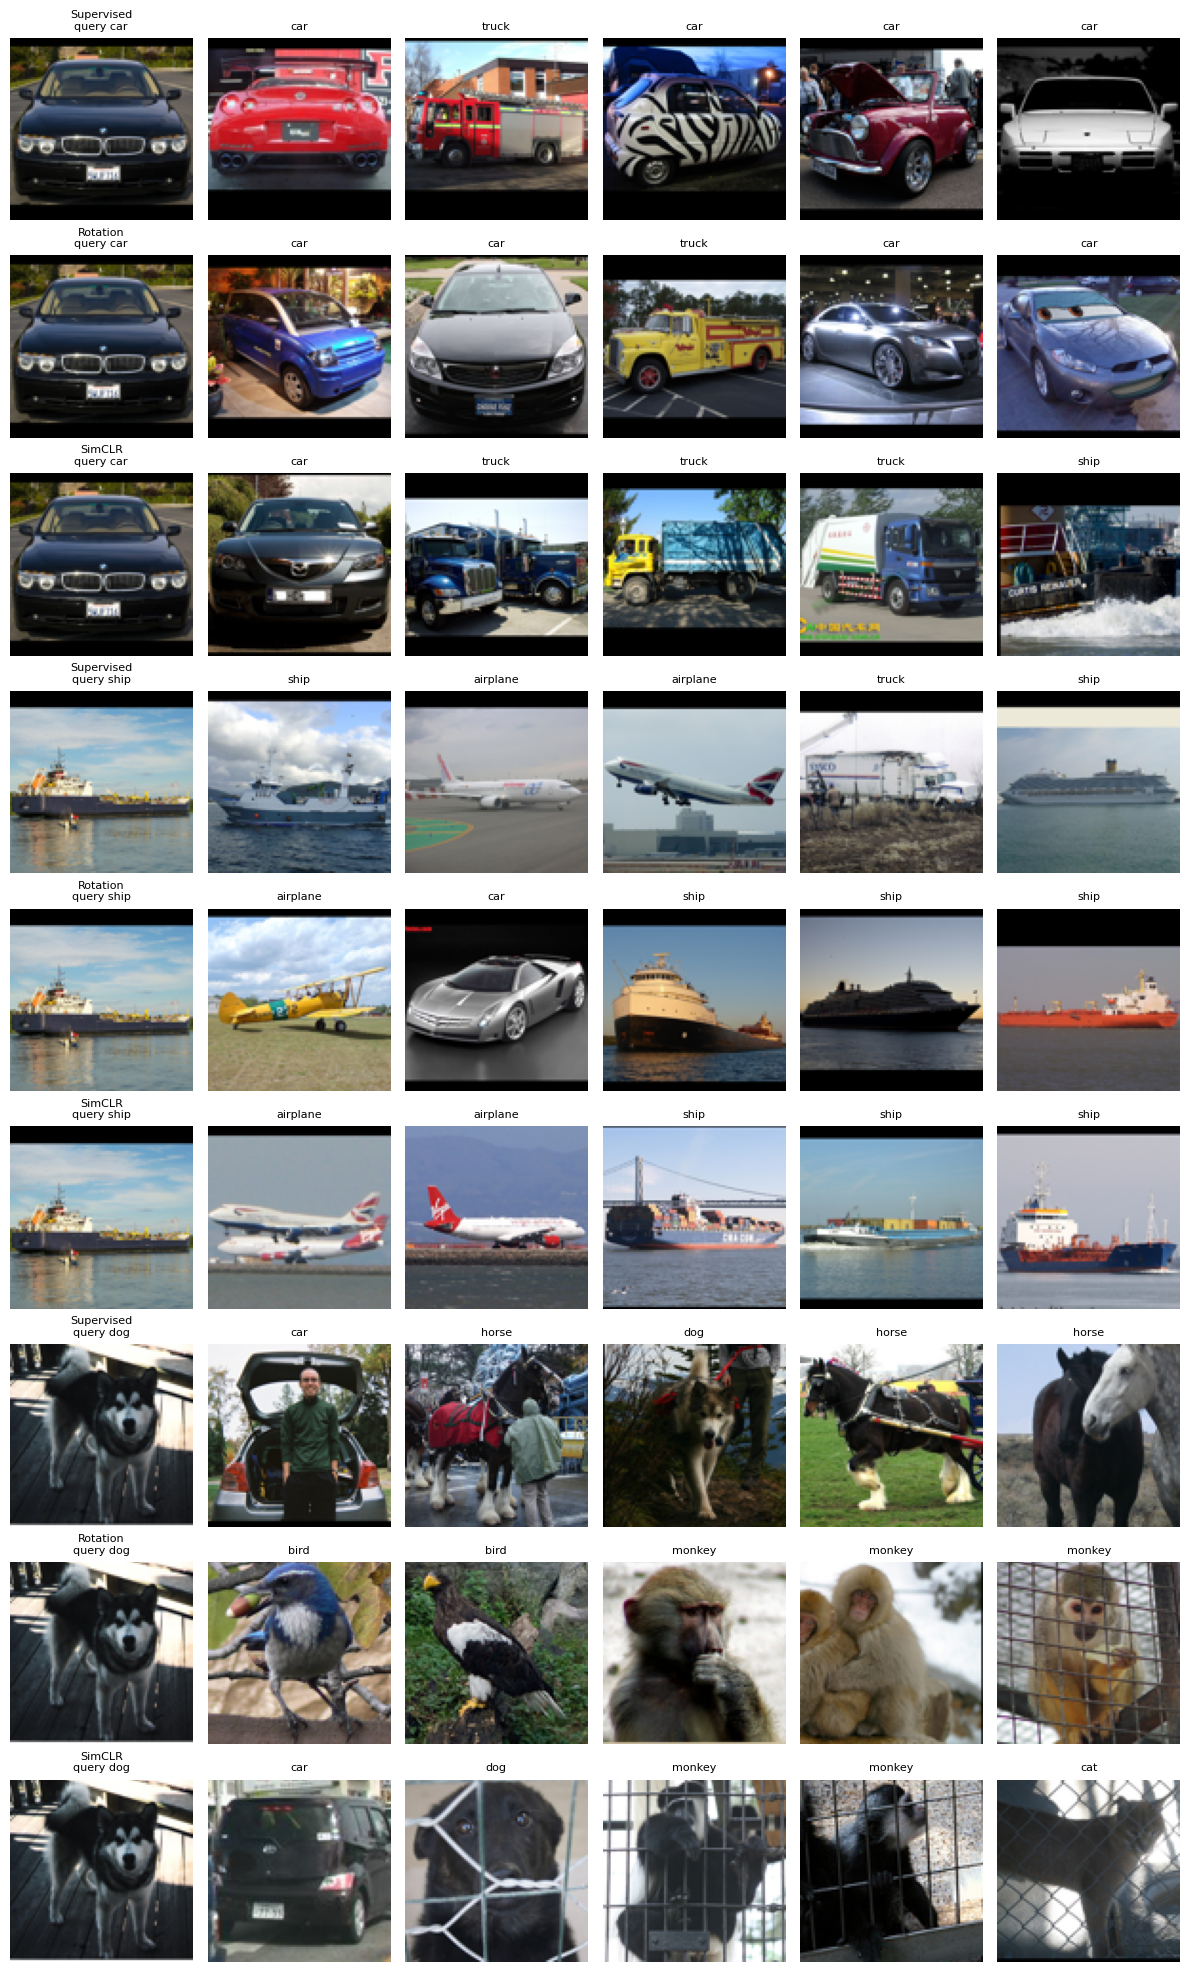

saved figures/nearest_neighbors.png


In [ ]:
@torch.no_grad()
def all_embeddings(embed_fn):
    feats = []
    labels = []
    for x, y in test_loader:
        z = embed_fn(x.to(DEVICE))
        z = F.normalize(z, dim=1)
        feats.append(z.cpu())
        labels.append(y)
    return torch.cat(feats), torch.cat(labels)

def show_neighbors(query_ids, banks, path):
    raw = STL10(ROOT, split="test", download=False)
    names = raw.classes
    n_q = len(query_ids)
    fig, axes = plt.subplots(n_q * 3, 6, figsize=(12, 2.2 * n_q * 3))
    row = 0
    for q in query_ids:
        q_img, q_y = raw[q]
        for name, (feats, labels) in banks.items():
            sims = feats @ feats[q]
            sims[q] = -1
            top = torch.topk(sims, 5).indices.tolist()
            axes[row, 0].imshow(q_img)
            axes[row, 0].set_title(f"{name}\nquery {names[q_y]}", fontsize=8)
            axes[row, 0].axis("off")
            for j, idx in enumerate(top):
                img, y = raw[idx]
                axes[row, j + 1].imshow(img)
                axes[row, j + 1].set_title(names[y], fontsize=8)
                axes[row, j + 1].axis("off")
            row += 1
    fig.tight_layout()
    fig.savefig(path, dpi=140)
    plt.show()
    print("saved", path)

g2 = torch.Generator().manual_seed(SEED)
query_ids = torch.randperm(len(test_set), generator=g2)[:3].tolist()
print("query indices:", query_ids)

model_a.eval()
model_b.eval()
model_c.eval()
banks = {
    "Supervised": all_embeddings(model_a.embed),
    "Rotation": all_embeddings(model_b.embed),
    "SimCLR": all_embeddings(model_c.embed),
}
show_neighbors(query_ids, banks, FIG / "nearest_neighbors.png")


In [ ]:
!zip -r hw6_results.zip checkpoints figures

  adding: checkpoints/ (stored 0%)
  adding: checkpoints/part_c_simclr.pt (deflated 7%)
  adding: checkpoints/part_b_rotation.pt (deflated 7%)
  adding: checkpoints/part_c_linear.pt (deflated 7%)
  adding: checkpoints/part_b_linear.pt (deflated 7%)
  adding: checkpoints/labeled_10pct_idx.pt (deflated 43%)
  adding: checkpoints/part_a.pt (deflated 7%)
  adding: checkpoints/simclr_20k_idx.pt (deflated 26%)
  adding: figures/ (stored 0%)
  adding: figures/nearest_neighbors.png (deflated 0%)


## Comparison

Test accuracy is on all 8,000 test images. Parts A, B, and C use the same 500 labeled images. For B and C the encoder stays frozen and only the linear layer trains.

| Model | Test accuracy |
|-------|--------------:|
| A supervised | 0.3426 |
| B rotation | 0.4260 |
| C SimCLR | 0.4980 |

SimCLR is the best. It trained on 20,000 unlabeled images, two augmented views each, cosine similarity, τ = 0.2. The four augmentations are the Demo 6 set: random resized crop, horizontal flip, color jitter, and random grayscale. The projection head comes off before the linear probe. Those 512-d features already separate classes better than the other two encoders, so a linear layer on 500 labels reaches 0.4980. Contrastive loss was still falling at epoch 15 (3.3600 to 1.6038). Epoch 14 of the probe was 0.5012.

Rotation is in the middle, 0.4260. It saw all 100,000 unlabeled images, and the label was only the rotation: 0°, 90°, 180°, or 270°. That beats a supervised net trained on 500 class labels. Predicting which way is up does not have to separate a dog from a monkey. Rotation loss was still falling at epoch 15 (0.9340 to 0.2880).

Supervised is last, 0.3426. It is the only encoder that saw class labels, and it only saw 500 images. Train loss ended at 0.1047. Test accuracy was highest on the last epoch. It fit the small labeled set.

What I would change:

- Supervised: augment those 500 images. More than 10% of the labels would matter more than extra epochs. This run already peaked at epoch 12.
- Rotation: add color jitter so the encoder cannot ignore color, and train the linear probe longer. Probe loss was still 1.5839 at epoch 15.
- SimCLR: use all 100,000 unlabeled images, train past 15 epochs, and raise the batch above 128. This loss wants a big batch, and the loss was still going down.

Nearest neighbors use the same three test queries for every encoder: index 3806 (car), 1720 (ship), 2051 (dog). Top 5 are cosine similarity in the 512-d encoder features. The figure is `figures/nearest_neighbors.png`.

The car query is clean for supervised and rotation: 4 of 5 neighbors are cars, and the other is a truck. SimCLR returns one car, three trucks, and a ship. Those are large vehicles, so the features are related, and the class is wrong.

The ship query flips. Rotation and SimCLR each return 3 ships. Supervised returns 2 ships, then airplanes and a truck.

The dog query is weak for all three. Supervised returns one dog, three horses, and a car. SimCLR returns one dog, two monkeys, a cat, and a car. Rotation returns two birds and three monkeys, and no dog. Close-up animal faces sit next to each other.

The probe and the grid disagree on the car. SimCLR has the highest test accuracy, and its car neighbors are the loosest of the three. I trust the 8,000-image probe for which model is best. The grid shows the features still mix classes that look alike, especially animals.
